In [ ]:
!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
import eli5

#dataset pre-processing realated imports
import sklearn
from eli5.sklearn import PermutationImportance
from urllib.parse import urlparse
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


#imports related to classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier

#DNN imports
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau

#Explainability imports
from sklearn.inspection import PartialDependenceDisplay

#to save the3 model
import joblib

In [ ]:
csic_filepath='/content/drive/MyDrive/ISM/csic_database.csv'
csic_data=pd.read_csv(csic_filepath)
print('Done!')

Done!


In [ ]:
n_features=csic_data.shape[1]
n_samples =csic_data.shape[0]


print("Number of samples:", n_samples)
print("Number of features:", n_features)

Number of samples: 61065
Number of features: 17


In [ ]:
csic_data.head(5)

,Unnamed: 0,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,cookie,content-type,connection,lenght,content,classification,URL
0,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=1F767F17239C9B670A39E9B10C3825F4,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/index.jsp HTTP/1.1
1,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=81761ACA043B0E6014CA42A4BCD06AB5,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/anadir.j...
2,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=933185092E0B668B90676E0A2B0767AF,application/x-www-form-urlencoded,Connection: close,Content-Length: 68,id=3&nombre=Vino+Rioja&precio=100&cantidad=55&...,0,http://localhost:8080/tienda1/publico/anadir.j...
3,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=8FA18BA82C5336D03D3A8AFA3E68CBB0,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/autentic...
4,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=7104E6C68A6BCF1423DAE990CE49FEE2,application/x-www-form-urlencoded,Connection: close,Content-Length: 63,modo=entrar&login=choong&pwd=d1se3ci%F3n&remem...,0,http://localhost:8080/tienda1/publico/autentic...


In [ ]:
csic_data.tail()

,Unnamed: 0,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,cookie,content-type,connection,lenght,content,classification,URL
61060,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=62216ADBBD9B91E17CA9AFEDCCC36275,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/miembros/editar....
61061,Anomalous,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=2317F5C0B1B7FAD18EB425E98DB102A3,application/x-www-form-urlencoded,Connection: close,Content-Length: 255,modo=registro&login=beaumont&password=quEratIt...,1,http://localhost:8080/tienda1/miembros/editar....
61062,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=7F0BA54A88B849EF752006D388E15CDD,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/miembros/editar....
61063,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=FB018FFB06011CFABD60D8E8AD58CA21,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/imagenes/3.gif/ ...
61064,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=3CC12010CDA952F123240EBAD79B55CC,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/imagenes/nuestra...


In [ ]:
csic_data.columns

Index(['Unnamed: 0', 'Method', 'User-Agent', 'Pragma', 'Cache-Control',
       'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host',
       'cookie', 'content-type', 'connection', 'lenght', 'content',
       'classification', 'URL'],
      dtype='object')

<Axes: xlabel='Unnamed: 0', ylabel='count'>

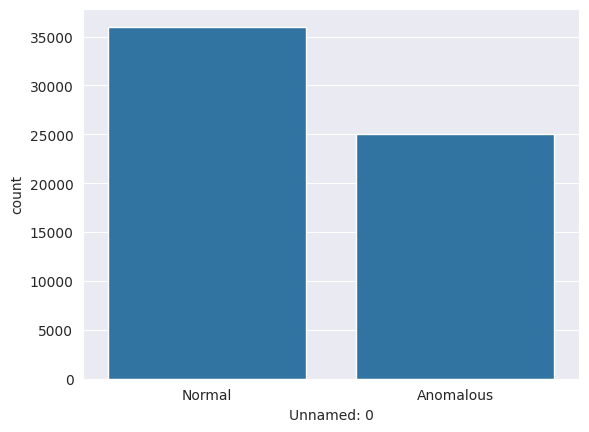

In [ ]:
sns.set_style('darkgrid')
sns.countplot(data=csic_data, x='Unnamed: 0')

In [ ]:
feature_names=[ 'Unnamed: 0','Method', 'User-Agent', 'Pragma', 'Cache-Control',
       'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host',
       'cookie', 'content-type', 'connection', 'lenght', 'content','classification',
        'URL']

X=csic_data[feature_names]
print(X)

      Unnamed: 0 Method                                         User-Agent  \
0         Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
1         Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
2         Normal   POST  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
3         Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
4         Normal   POST  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
...          ...    ...                                                ...   
61060  Anomalous    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
61061  Anomalous   POST  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
61062  Anomalous    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
61063  Anomalous    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
61064  Anomalous    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   

         Pragma Cache-Control  \
0      no-cache      no-cache 

In [ ]:
# Find columns where number of unique values = 1
single_value_cols = [col for col in csic_data.columns if csic_data[col].nunique() == 1]

print("Columns with only one unique value:")
print(single_value_cols)

Columns with only one unique value:
['User-Agent', 'Pragma', 'Cache-Control', 'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'content-type']


In [ ]:
csic_data.columns

Index(['Unnamed: 0', 'Method', 'User-Agent', 'Pragma', 'Cache-Control',
       'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host',
       'cookie', 'content-type', 'connection', 'lenght', 'content',
       'classification', 'URL'],
      dtype='object')

In [ ]:
# Removing not discriminatory Features and making some adjustments on feature names
X = X.rename(columns={'Unnamed: 0': 'Class'})
X = X.rename(columns={'lenght': 'content_length'})


feature_names=[ 'Class','Method','host','cookie','Accept', 'content_length', 'content','classification','URL']

# Print the remaining data
X = X[feature_names]
print(X)

           Class Method            host  \
0         Normal    GET  localhost:8080   
1         Normal    GET  localhost:8080   
2         Normal   POST  localhost:8080   
3         Normal    GET  localhost:8080   
4         Normal   POST  localhost:8080   
...          ...    ...             ...   
61060  Anomalous    GET  localhost:8080   
61061  Anomalous   POST  localhost:8080   
61062  Anomalous    GET  localhost:8080   
61063  Anomalous    GET  localhost:8080   
61064  Anomalous    GET  localhost:8080   

                                            cookie  \
0      JSESSIONID=1F767F17239C9B670A39E9B10C3825F4   
1      JSESSIONID=81761ACA043B0E6014CA42A4BCD06AB5   
2      JSESSIONID=933185092E0B668B90676E0A2B0767AF   
3      JSESSIONID=8FA18BA82C5336D03D3A8AFA3E68CBB0   
4      JSESSIONID=7104E6C68A6BCF1423DAE990CE49FEE2   
...                                            ...   
61060  JSESSIONID=62216ADBBD9B91E17CA9AFEDCCC36275   
61061  JSESSIONID=2317F5C0B1B7FAD18EB425E98DB102A3 

In [ ]:
y=X.Class
print(y)

0           Normal
1           Normal
2           Normal
3           Normal
4           Normal
           ...    
61060    Anomalous
61061    Anomalous
61062    Anomalous
61063    Anomalous
61064    Anomalous
Name: Class, Length: 61065, dtype: object


In [ ]:
size=X.shape[1]
# Get list of categorical variables
s = (X.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables:")
print(object_cols)

Categorical variables:
['Class', 'Method', 'host', 'cookie', 'Accept', 'content_length', 'content', 'URL']


**Pre-processing on the feature: Content Length**

In [ ]:
print(X.content_length)

0                        NaN
1                        NaN
2         Content-Length: 68
3                        NaN
4         Content-Length: 63
                ...         
61060                    NaN
61061    Content-Length: 255
61062                    NaN
61063                    NaN
61064                    NaN
Name: content_length, Length: 61065, dtype: object


In [ ]:
#replace NaN values with 0
#removing the 'Content-Lenght' string and keeping only the numerical value

X['content_length'] = X['content_length'].astype(str)
X['content_length'] = X['content_length'].str.extract(r'(\d+)')
X['content_length'] = pd.to_numeric(X['content_length'], errors='coerce').fillna(0)
print(X.content_length)

0          0.0
1          0.0
2         68.0
3          0.0
4         63.0
         ...  
61060      0.0
61061    255.0
61062      0.0
61063      0.0
61064      0.0
Name: content_length, Length: 61065, dtype: float64


In [ ]:
filtered_length = X.loc[X['Method'] == 'GET', 'content_length']
print(filtered_length)

0        0.0
1        0.0
3        0.0
5        0.0
7        0.0
        ... 
61058    0.0
61060    0.0
61062    0.0
61063    0.0
61064    0.0
Name: content_length, Length: 43088, dtype: float64


**URL PRE-PROCESSING**

In [ ]:
url_counts = X['URL'].value_counts()
most_common_urls = url_counts.head(10)  # Extract the top 10 most common strings

print("Most common URLs:")
for i, (url, count) in enumerate(most_common_urls.items(), 1):
    print(f"{i}. URL: {url} - Count: {count}")

Most common URLs:
1. URL: http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1 - Count: 2441
2. URL: http://localhost:8080/tienda1/publico/autenticar.jsp HTTP/1.1 - Count: 2422
3. URL: http://localhost:8080/tienda1/publico/registro.jsp HTTP/1.1 - Count: 2417
4. URL: http://localhost:8080/tienda1/miembros/editar.jsp HTTP/1.1 - Count: 2412
5. URL: http://localhost:8080/tienda1/publico/pagar.jsp HTTP/1.1 - Count: 2379
6. URL: http://localhost:8080/tienda1/publico/caracteristicas.jsp HTTP/1.1 - Count: 2003
7. URL: http://localhost:8080/tienda1/publico/vaciar.jsp HTTP/1.1 - Count: 1965
8. URL: http://localhost:8080/tienda1/publico/entrar.jsp HTTP/1.1 - Count: 1938
9. URL: http://localhost:8080/tienda1/miembros/imagenes/ogono.jpg HTTP/1.1 - Count: 1000
10. URL: http://localhost:8080/tienda1/miembros/fotos.jsp HTTP/1.1 - Count: 1000


**Utils for URL/Content pre-processing**

In [ ]:
def count_dot(url):
    count_dot = url.count('.')
    return count_dot


def no_of_dir(url):
    urldir = urlparse(url).path
    return urldir.count('/')

def no_of_embed(url):
    urldir = urlparse(url).path
    return urldir.count('//')

def shortening_service(url):
    match = re.search(
        r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
        r'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
        r'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
        r'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
        r'db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
        r'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
        r'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
        r'tr\.im|link\.zip\.net',
        url
    )
    return 1 if match else 0


def count_http(url):
    return url.count('http')

def count_per(url):
    return url.count('%')

def count_ques(url):
    return url.count('?')

def count_hyphen(url):
    return url.count('-')


def count_equal(url):
    return url.count('=')


def url_length(url):
    return len(str(url))

#Hostname Length

def hostname_length(url):
    return len(urlparse(url).netloc)


import re

def suspicious_words(url):
    score_map = {
        'error': 30,
        'errorMsg': 30,
        'id': 10,
        'errorID': 30,
        'SELECT': 50,
        'FROM': 50,
        'WHERE': 50,
        'DELETE': 50,
        'USERS': 50,
        'DROP': 50,
        'CREATE': 50,
        'INJECTED': 50,
        'TABLE': 50,
        'alert': 30,
        'javascript': 20,
        'cookie': 25,
        '--': 30,
        '.exe': 30,
        '.php': 20,
        '.js': 10,
        'admin': 10,
        'administrator': 10,
        '\'': 30,
        'password': 15,
        'login': 15,
        'incorrect': 20,
        'pwd': 15,
        'tamper': 25,
        'vaciar': 20,
        'carrito': 25,
        'wait': 30,
        'delay': 35,
        'set': 20,
        'steal': 35,
        'hacker': 35,
        'proxy': 35,
        'location': 30,
        'document.cookie': 40,
        'document': 20,
        'set-cookie': 40,
        'create': 40,
        'cmd': 40,
        'dir': 30,
        'shell': 40,
        'reverse': 30,
        'bin': 20,
        'cookiesteal': 40,
        'LIKE': 30,
        'UNION': 35,
        'include': 30,
        'file': 20,
        'tmp': 25,
        'ssh': 40,
        'exec': 30,
        'cat': 25,
        'etc': 30,
        'fetch': 25,
        'eval': 30,
        'wait': 30,
        'malware': 45,
        'ransomware': 45,
        'phishing': 45,
        'exploit': 45,
        'virus': 45,
        'trojan': 45,
        'backdoor': 45,
        'spyware': 45,
        'rootkit': 45,
        'credential': 30,
        'inject': 30,
        'script': 25,
        'iframe': 25,
        'src=': 25,
        'onerror': 30,
        'prompt': 20,
        'confirm': 20,
        'eval': 25,
        'expression': 30,
        r'function\(': 20,
        'xmlhttprequest': 30,
        'xhr': 20,
        'window.': 20,
        'document.': 20,
        'cookie': 25,
        'click': 15,
        'mouseover': 15,
        'onload': 20,
        'onunload': 20,
    }

    matches = re.findall(r'(?i)' + '|'.join(score_map.keys()), url)

    total_score = sum(score_map.get(match.lower(), 0) for match in matches)
    return total_score


def digit_count(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits = digits + 1
    return digits

def letter_count(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters += 1
    return letters

def count_special_characters(url):
    special_characters = re.sub(r'[a-zA-Z0-9\s]', '', url)
    count = len(special_characters)
    return count


# Number of Parameters in URL
def number_of_parameters(url):
    params = urlparse(url).query
    return 0 if params == '' else len(params.split('&'))

# Number of Fragments in URL
def number_of_fragments(url):
    frags = urlparse(url).fragment
    return len(frags.split('#')) - 1 if frags == '' else 0

# URL is Encoded
def is_encoded(url):
    return int('%' in url.lower())


def unusual_character_ratio(url):
    total_characters = len(url)
    unusual_characters = re.sub(r'[a-zA-Z0-9\s\-._]', '', url)
    unusual_count = len(unusual_characters)
    ratio = unusual_count / total_characters if total_characters > 0 else 0
    return ratio

In [ ]:
X['count_dot_url'] = X['URL'].apply(count_dot)
X['count_dir_url'] = X['URL'].apply(no_of_dir)
X['count_embed_domain_url'] = X['URL'].apply(no_of_embed)
X['short_url'] = X['URL'].apply(shortening_service)
X['count-http'] = X['URL'].apply(count_http)
X['count%_url'] = X['URL'].apply(count_per)
X['count?_url'] = X['URL'].apply(count_ques)
X['count-_url'] = X['URL'].apply(count_hyphen)
X['count=_url'] = X['URL'].apply(count_equal)
X['hostname_length_url'] = X['URL'].apply(hostname_length)
X['sus_url'] = X['URL'].apply(suspicious_words)
X['count-digits_url'] = X['URL'].apply(digit_count)
X['count-letters_url'] = X['URL'].apply(letter_count)
X['url_length'] = X['URL'].apply(url_length)
X['number_of_parameters_url'] = X['URL'].apply(number_of_parameters)
X['number_of_fragments_url'] = X['URL'].apply(number_of_fragments)
X['is_encoded_url'] = X['URL'].apply(is_encoded)
X['special_count_url'] = X['URL'].apply(count_special_characters)
X['unusual_character_ratio_url'] = X['URL'].apply(unusual_character_ratio)

In [ ]:
# Select the features and class variable for plotting
new_features = ['count_dot_url', 'count_dir_url', 'count_embed_domain_url', 'count-http',
                'count%_url', 'count?_url', 'count-_url', 'count=_url', 'url_length', 'hostname_length_url',
                'sus_url', 'count-digits_url', 'count-letters_url', 'number_of_parameters_url',
                'number_of_fragments_url', 'is_encoded_url','special_count_url','unusual_character_ratio_url']

# Create a DataFrame with the selected features
set = X[new_features]

for new_feature in X.columns:
    if new_feature in X.columns:
        unique_count = X[new_feature].nunique()
        print(f"Number of unique values for {new_feature}: {unique_count}")
    else:
        print(f"Column '{new_feature}' does not exist in the DataFrame.")

Number of unique values for Class: 2
Number of unique values for Method: 3
Number of unique values for host: 2
Number of unique values for cookie: 61065
Number of unique values for Accept: 1
Number of unique values for content_length: 383
Number of unique values for content: 12091
Number of unique values for classification: 2
Number of unique values for URL: 13498
Number of unique values for count_dot_url: 9
Number of unique values for count_dir_url: 7
Number of unique values for count_embed_domain_url: 2
Number of unique values for short_url: 2
Number of unique values for count-http: 2
Number of unique values for count%_url: 34
Number of unique values for count?_url: 2
Number of unique values for count-_url: 8
Number of unique values for count=_url: 5
Number of unique values for hostname_length_url: 5
Number of unique values for sus_url: 61
Number of unique values for count-digits_url: 112
Number of unique values for count-letters_url: 259
Number of unique values for url_length: 417
N

**Removing Cookies as feature**

In [ ]:
unique_count = X['cookie'].nunique()
print(f"Count of unique values in 'cookie': {unique_count}")

Count of unique values in 'cookie': 61065


**Encoding categorical features**

In [ ]:
X['Accept'] = X['Accept'].astype(str)
X['Accept'] = X['Accept'].str.extract(r'(\d+)')
X['Accept'] = pd.to_numeric(X['Accept'], errors='coerce').fillna(1)

In [ ]:
lb_make = LabelEncoder()
X["Method_enc"] = lb_make.fit_transform(X["Method"])
X["host_enc"] =lb_make.fit_transform(X["host"])
X["Accept_enc"] =lb_make.fit_transform(X["Accept"])

In [ ]:
unique_count_met = X["Method_enc"].nunique()
unique_count_host = X["host_enc"].nunique()
unique_count_acc = X["Accept_enc"].nunique()


print(f"Number of unique values for 'Method_enc': {unique_count_met}")
print(f"Number of unique values for 'host_enc': {unique_count_host}")
print(f"Number of unique values for 'Accept_enc': {unique_count_acc}")

Number of unique values for 'Method_enc': 3
Number of unique values for 'host_enc': 2
Number of unique values for 'Accept_enc': 2


In [ ]:
X.head()

,Class,Method,host,cookie,Accept,content_length,content,classification,URL,count_dot_url,...,count-letters_url,url_length,number_of_parameters_url,number_of_fragments_url,is_encoded_url,special_count_url,unusual_character_ratio_url,Method_enc,host_enc,Accept_enc
0,Normal,GET,localhost:8080,JSESSIONID=1F767F17239C9B670A39E9B10C3825F4,0.0,0.0,NaN,0,http://localhost:8080/tienda1/index.jsp HTTP/1.1,2,...,31,48,0,0,0,9,0.145833,0,0,0
1,Normal,GET,localhost:8080,JSESSIONID=81761ACA043B0E6014CA42A4BCD06AB5,0.0,0.0,NaN,0,http://localhost:8080/tienda1/publico/anadir.j...,2,...,86,126,5,0,1,24,0.174603,0,0,0
2,Normal,POST,localhost:8080,JSESSIONID=933185092E0B668B90676E0A2B0767AF,0.0,68.0,id=3&nombre=Vino+Rioja&precio=100&cantidad=55&...,0,http://localhost:8080/tienda1/publico/anadir.j...,2,...,39,57,0,0,0,10,0.140351,1,0,0
3,Normal,GET,localhost:8080,JSESSIONID=8FA18BA82C5336D03D3A8AFA3E68CBB0,0.0,0.0,NaN,0,http://localhost:8080/tienda1/publico/autentic...,2,...,92,125,5,0,1,21,0.152000,0,0,0
4,Normal,POST,localhost:8080,JSESSIONID=7104E6C68A6BCF1423DAE990CE49FEE2,0.0,63.0,modo=entrar&login=choong&pwd=d1se3ci%F3n&remem...,0,http://localhost:8080/tienda1/publico/autentic...,2,...,43,61,0,0,0,10,0.131148,1,0,0


In [ ]:
X.tail()

,Class,Method,host,cookie,Accept,content_length,content,classification,URL,count_dot_url,...,count-letters_url,url_length,number_of_parameters_url,number_of_fragments_url,is_encoded_url,special_count_url,unusual_character_ratio_url,Method_enc,host_enc,Accept_enc
61060,Anomalous,GET,localhost:8080,JSESSIONID=62216ADBBD9B91E17CA9AFEDCCC36275,0.0,0.0,NaN,1,http://localhost:8080/tienda1/miembros/editar....,3,...,218,314,13,0,1,48,0.143312,0,0,0
61061,Anomalous,POST,localhost:8080,JSESSIONID=2317F5C0B1B7FAD18EB425E98DB102A3,0.0,255.0,modo=registro&login=beaumont&password=quEratIt...,1,http://localhost:8080/tienda1/miembros/editar....,2,...,40,58,0,0,0,10,0.137931,1,0,0
61062,Anomalous,GET,localhost:8080,JSESSIONID=7F0BA54A88B849EF752006D388E15CDD,0.0,0.0,NaN,1,http://localhost:8080/tienda1/miembros/editar....,3,...,43,62,0,0,0,11,0.129032,0,0,0
61063,Anomalous,GET,localhost:8080,JSESSIONID=FB018FFB06011CFABD60D8E8AD58CA21,0.0,0.0,NaN,1,http://localhost:8080/tienda1/imagenes/3.gif/ ...,2,...,34,54,0,0,0,11,0.166667,0,0,0
61064,Anomalous,GET,localhost:8080,JSESSIONID=3CC12010CDA952F123240EBAD79B55CC,0.0,0.0,NaN,1,http://localhost:8080/tienda1/imagenes/nuestra...,3,...,50,69,0,0,0,11,0.115942,0,0,0


In [ ]:
def apply_to_content(content,function):
    if pd.isna(content):
        return 0
    elif isinstance(content, str):
        return function(content)

#"""
#                'count_dot_content','count_dir_content','count_embed_domain_content','count%_content','count?_content',
 #               'count-_content','count=_content','hostname_length_content','sus_content','count_digits_content',
  #              'count_letters_content','content_length','number_of_parameters_content','number_of_fragments_content',
   #             'is_encoded_content','special_count_content','unusual_character_ratio_content'
    #            ]"""

X['count_dot_content'] = X['content'].apply(apply_to_content, function=count_dot)
X['count_dir_content'] = X['content'].apply(apply_to_content, function=no_of_dir)
X['count_embed_domain_content'] = X['content'].apply(apply_to_content, function=no_of_embed)
X['count%_content'] = X['content'].apply(apply_to_content, function=count_per)
X['count?_content'] = X['content'].apply(apply_to_content, function=count_ques)
X['count-_content'] = X['content'].apply(apply_to_content, function=count_hyphen)
X['count=_content'] = X['content'].apply(apply_to_content, function=count_equal)
X['content_length'] = X['content'].apply(apply_to_content, function=url_length)
X['sus_content'] = X['content'].apply(apply_to_content, function=suspicious_words)
X['count_digits_content'] = X['content'].apply(apply_to_content, function=digit_count)
X['count_letters_content'] = X['content'].apply(apply_to_content, function=letter_count)
X['special_count_content'] = X['content'].apply(apply_to_content, function=count_special_characters)
X['is_encoded_content'] = X['content'].apply(apply_to_content, function=is_encoded)
#X['unusual_character_ratio_content'] = X['content'].apply(apply_to_content, function=unusual_character_ratio)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the features and class variable for plotting
new_content_features = ['count_dot_content', 'count_dir_content', 'count_embed_domain_content', 'count%_content', 'count?_content',
                        'count-_content', 'count=_content', 'sus_content', 'count_digits_content',
                        'count_letters_content', 'content_length', 'is_encoded_content', 'special_count_content']

# Create a DataFrame with the selected features
selected_features_df = X[new_content_features]

for feature_name in selected_features_df.columns:
    if feature_name in X.columns:
        unique_count = selected_features_df[feature_name].nunique()
        print(f"Number of unique values for {feature_name}: {unique_count}")
    else:
        print(f"Column '{feature_name}' does not exist in the DataFrame.")

Number of unique values for count_dot_content: 8
Number of unique values for count_dir_content: 1
Number of unique values for count_embed_domain_content: 1
Number of unique values for count%_content: 34
Number of unique values for count?_content: 1
Number of unique values for count-_content: 8
Number of unique values for count=_content: 5
Number of unique values for sus_content: 57
Number of unique values for count_digits_content: 111
Number of unique values for count_letters_content: 230
Number of unique values for content_length: 383
Number of unique values for is_encoded_content: 2
Number of unique values for special_count_content: 87


In [ ]:
X.columns

Index(['Class', 'Method', 'host', 'cookie', 'Accept', 'content_length',
       'content', 'classification', 'URL', 'count_dot_url', 'count_dir_url',
       'count_embed_domain_url', 'short_url', 'count-http', 'count%_url',
       'count?_url', 'count-_url', 'count=_url', 'hostname_length_url',
       'sus_url', 'count-digits_url', 'count-letters_url', 'url_length',
       'number_of_parameters_url', 'number_of_fragments_url', 'is_encoded_url',
       'special_count_url', 'unusual_character_ratio_url', 'Method_enc',
       'host_enc', 'Accept_enc', 'count_dot_content', 'count_dir_content',
       'count_embed_domain_content', 'count%_content', 'count?_content',
       'count-_content', 'count=_content', 'sus_content',
       'count_digits_content', 'count_letters_content',
       'special_count_content', 'is_encoded_content'],
      dtype='object')

**Building the final dataset to use for the classification**

In [ ]:
labels=['count_dot_url', 'count_dir_url', 'count_embed_domain_url', 'count-http',
                'count%_url', 'count?_url', 'count-_url', 'count=_url', 'url_length', 'hostname_length_url',
                'sus_url', 'count-digits_url', 'count-letters_url', 'number_of_parameters_url',
                'is_encoded_url','special_count_url','unusual_character_ratio_url',
                 #method
                'Method_enc',
                #content
                'count_dot_content','count%_content',
                 'count-_content','count=_content','sus_content','count_digits_content',
                  'count_letters_content','content_length',
               'is_encoded_content','special_count_content']
print(X[labels])

       count_dot_url  count_dir_url  count_embed_domain_url  count-http  \
0                  2              3                       0           1   
1                  2              3                       0           1   
2                  2              4                       0           1   
3                  2              3                       0           1   
4                  2              4                       0           1   
...              ...            ...                     ...         ...   
61060              3              3                       0           1   
61061              2              4                       0           1   
61062              3              4                       0           1   
61063              2              5                       0           1   
61064              3              4                       0           1   

       count%_url  count?_url  count-_url  count=_url  url_length  \
0               0           0 

In [ ]:
y=X['classification']
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
61060    1
61061    1
61062    1
61063    1
61064    1
Name: classification, Length: 61065, dtype: int64


In [ ]:
print('computing...)')
#split dataset in test and train
x_tr, x_ts, y_tr, y_ts = train_test_split(X[labels], y, test_size=0.3, random_state=0)


print('Done!')

computing...)
Done!


In [ ]:
x_tr.head(5)

,count_dot_url,count_dir_url,count_embed_domain_url,count-http,count%_url,count?_url,count-_url,count=_url,url_length,hostname_length_url,...,count_dot_content,count%_content,count-_content,count=_content,sus_content,count_digits_content,count_letters_content,content_length,is_encoded_content,special_count_content
23480,2,3,0,1,0,1,0,1,91,14,...,0,0,0,0,0,0,0,0,0,0
45171,2,3,0,1,14,1,2,1,125,14,...,0,0,0,0,0,0,0,0,0,0
9460,2,4,0,1,0,0,0,0,57,14,...,0,0,0,0,0,0,0,0,0,0
9905,2,3,0,1,0,1,0,1,71,14,...,0,0,0,0,0,0,0,0,0,0
8937,2,4,0,1,0,0,0,0,57,14,...,0,0,0,1,50,0,31,33,0,2


In [ ]:
x_tr.tail(5)

,count_dot_url,count_dir_url,count_embed_domain_url,count-http,count%_url,count?_url,count-_url,count=_url,url_length,hostname_length_url,...,count_dot_content,count%_content,count-_content,count=_content,sus_content,count_digits_content,count_letters_content,content_length,is_encoded_content,special_count_content
45891,2,3,0,1,0,1,0,1,76,14,...,0,0,0,0,0,0,0,0,0,0
52416,2,4,0,1,0,0,0,0,57,14,...,0,0,0,1,50,0,32,34,0,2
42613,2,3,0,1,0,1,0,3,95,14,...,0,0,0,0,0,0,0,0,0,0
43567,3,3,0,1,4,1,0,13,324,14,...,0,0,0,0,0,0,0,0,0,0
2732,2,4,0,1,0,0,0,0,53,14,...,0,0,0,0,0,0,0,0,0,0


**Classifiers**

RANDOM **FOREST**

In [ ]:
random_forest_model = RandomForestClassifier(random_state=1000)
print('Computing....')
# Fit the model
random_forest_model.fit(x_tr,y_tr)
print('Done!')

Computing....
Done!


In [ ]:
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(random_forest_model, threshold="mean")
X_train_selected = selector.transform(x_tr)
X_test_selected = selector.transform(x_ts)

svm = SVC(kernel='rbf', C=2, gamma='scale')  # You can tune these hyperparameters
svm.fit(X_train_selected, y_tr)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


SVC(C=2)

In [ ]:
y_pred = svm.predict(X_test_selected)
accuracy = accuracy_score(y_ts, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_ts, y_pred))

Accuracy: 0.72
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.86      0.78     10753
           1       0.73      0.52      0.61      7567

    accuracy                           0.72     18320
   macro avg       0.72      0.69      0.70     18320
weighted avg       0.72      0.72      0.71     18320



In [ ]:
RT_predictions= random_forest_model.predict(x_ts)
print('MAE', mean_absolute_error(y_ts, RT_predictions))
print("Accuracy", accuracy_score(y_ts, RT_predictions))
print("Precision", precision_score(y_ts, RT_predictions, average='weighted', labels=np.unique(RT_predictions)))
print("Recall", recall_score(y_ts, RT_predictions, average='weighted', labels=np.unique(RT_predictions)))
print("F1", f1_score(y_ts, RT_predictions, average='weighted', labels=np.unique(RT_predictions)))
print("ROC AUC", roc_auc_score(y_ts, RT_predictions, average='weighted', labels=np.unique(RT_predictions)))
error_rt = (RT_predictions != y_ts).mean()
print("Test error: {:.1%}".format(error_rt))


# save the model
filename = 'APPLICATION LAYER.sav'
joblib.dump(random_forest_model, open(filename, 'wb'))

MAE 0.07374454148471615
Accuracy 0.9262554585152838
Precision 0.9261917594808624
Recall 0.9262554585152838
F1 0.9262150260558555
ROC AUC 0.9234171756395833
Test error: 7.4%


In [ ]:
import joblib

# Save model
joblib.dump(random_forest_model, "rf_model.pkl")

# Save feature column order
joblib.dump(labels, "feature_columns.pkl")

['feature_columns.pkl']

In [ ]:
print(y_tr.unique())
print(y_tr.name)

[0 1]
classification


In [ ]:
x_ts = x_ts.reset_index(drop=True)
y_ts = y_ts.reset_index(drop=True)

for k in range(np.unique(y_ts).size):
    print('mean of class ' + str(k) + ':\n', x_ts[y_ts == k].mean(axis=0))

mean of class 0:
 count_dot_url                   2.072631
count_dir_url                   3.831210
count_embed_domain_url          0.000000
count-http                      1.000000
count%_url                      0.273319
count?_url                      0.221706
count-_url                      0.024644
count=_url                      1.173812
url_length                     79.160606
hostname_length_url            14.000000
sus_url                        21.204315
count-digits_url                9.812703
count-letters_url              55.086766
number_of_parameters_url        1.173812
is_encoded_url                  0.090951
special_count_url              13.261136
unusual_character_ratio_url     0.140332
Method_enc                      0.226448
count_dot_content               0.073189
count%_content                  0.272110
count-_content                  0.024644
count=_content                  1.189529
sus_content                    10.676090
count_digits_content            2.77104

In [ ]:
print(classification_report(y_ts, RT_predictions, target_names = ['Normal (class 0)','Anomalous (class 1)']))

                     precision    recall  f1-score   support

   Normal (class 0)       0.93      0.94      0.94     10753
Anomalous (class 1)       0.91      0.91      0.91      7567

           accuracy                           0.93     18320
          macro avg       0.92      0.92      0.92     18320
       weighted avg       0.93      0.93      0.93     18320



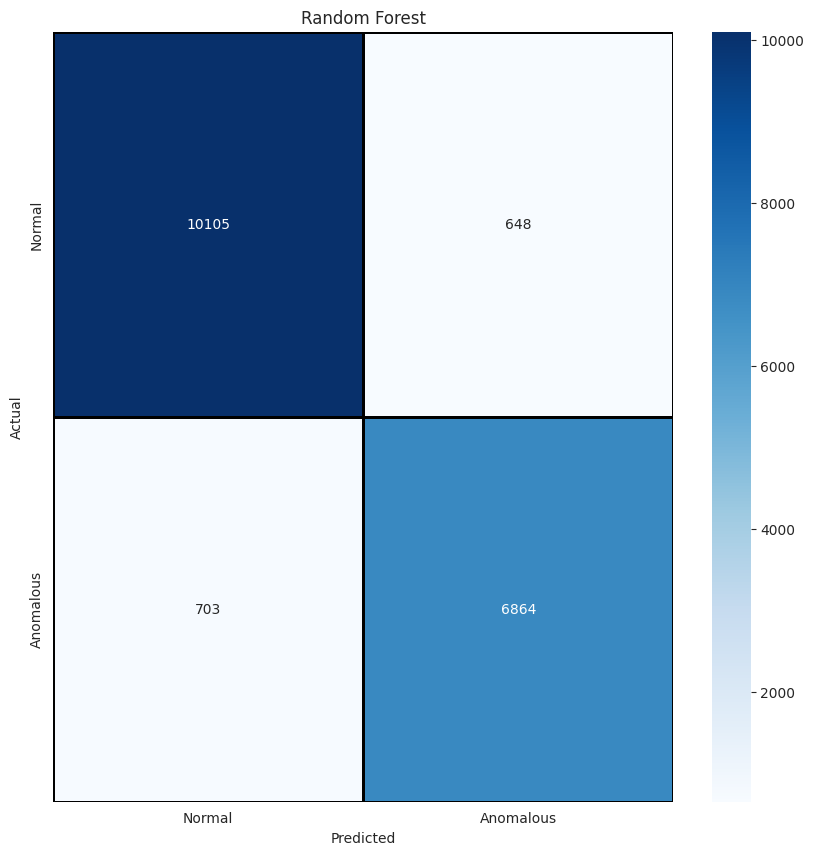

In [ ]:
label = ['Normal', 'Anomalous']
cm = confusion_matrix(y_ts, RT_predictions)
cm = pd.DataFrame(cm, index=['0', '1'], columns=['0', '1'])

plt.figure(figsize=(10, 10))
sns.heatmap(cm, cmap="Blues", linecolor='black', linewidth=1, annot=True, fmt='', xticklabels=label, yticklabels=label)
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**DECISION TREE**

In [ ]:
DT_model = DecisionTreeClassifier(random_state=2)
print('Computing....')
DT_model.fit(x_tr,y_tr)
print('Done!')

Computing....
Done!


In [ ]:
DT_predictions= DT_model.predict(x_ts)
print('MAE', mean_absolute_error(y_ts, DT_predictions))
print("Accuracy", accuracy_score(y_ts, DT_predictions))
print("Precision", precision_score(y_ts, DT_predictions, average='weighted', labels=np.unique(DT_predictions)))
print("Recall", recall_score(y_ts, DT_predictions, average='weighted', labels=np.unique(DT_predictions)))
print("F1", f1_score(y_ts, DT_predictions, average='weighted', labels=np.unique(DT_predictions)))
print("ROC AUC", roc_auc_score(y_ts, DT_predictions, average='weighted', labels=np.unique(DT_predictions)))
error_dt = (DT_predictions != y_ts).mean()
print("Test error: {:.1%}".format(error_dt))

MAE 0.08133187772925764
Accuracy 0.9186681222707423
Precision 0.9185504062924272
Recall 0.9186681222707423
F1 0.9185072169864832
ROC AUC 0.9142717136873706
Test error: 8.1%


<Axes: title={'center': 'Decision Tree'}>

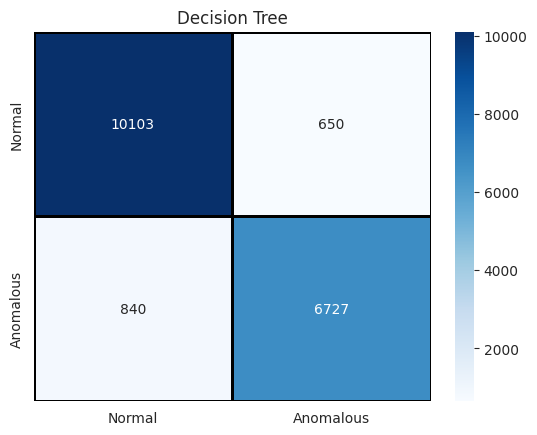

In [ ]:
cm = confusion_matrix(y_ts,DT_predictions)
cm = pd.DataFrame(cm , index = ['0','1'] , columns = ['0','1'])
plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='',xticklabels = label,yticklabels = label)

In [ ]:
# Save encoders
joblib.dump(lb_make, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
import joblib
import numpy as np

model  = joblib.load("/content/drive/MyDrive/ISM/rf_model.pkl")
labels = joblib.load("/content/drive/MyDrive/ISM/feature_columns.pkl")

# 1. Check class labels
print("=== Classes ===")
print(model.classes_)

# 2. Check class distribution in training
print("\n=== Class distribution in y ===")
print(y.value_counts())

# 3. Check what y actually contains
print("\n=== y dtype and unique values ===")
print("dtype:", y.dtype)
print("unique:", y.unique())

# 4. Predict on a known normal POST sample
import pandas as pd
sample = pd.DataFrame([{col: 0 for col in labels}])
# Simulate a clean POST request features
sample['Method_enc'] = 1          # POST
sample['content_length'] = 45
sample['count_letters_content'] = 35
sample['count_digits_content'] = 8
sample['count=_content'] = 2
sample['count-_content'] = 0
sample['sus_content'] = 0
sample['sus_url'] = 0

pred  = model.predict(sample[labels])
proba = model.predict_proba(sample[labels])
print("\n=== Sample POST prediction ===")
print("Predicted:", pred)
print("Probabilities:", dict(zip(model.classes_, proba[0].round(3))))

=== Classes ===
[0 1]

=== Class distribution in y ===
classification
0    36000
1    25065
Name: count, dtype: int64

=== y dtype and unique values ===
dtype: int64
unique: [0 1]

=== Sample POST prediction ===
Predicted: [1]
Probabilities: {np.int64(0): np.float64(0.1), np.int64(1): np.float64(0.9)}


In [ ]:
# Check how POST requests are distributed in training data
print("=== Method distribution in full dataset ===")
print(X['Method'].value_counts())

print("\n=== Class distribution per Method ===")
print(pd.crosstab(X['Method'], X['classification']))

print("\n=== Average sus_content for POST normal vs attack ===")
post_data = X[X['Method'] == 'POST']
print(post_data.groupby('classification')[['sus_content','content_length','count=_content','special_count_content']].mean())

=== Method distribution in full dataset ===
Method
GET     43088
POST    17580
PUT       397
Name: count, dtype: int64

=== Class distribution per Method ===
classification      0      1
Method                      
GET             28000  15088
POST             8000   9580
PUT                 0    397

=== Average sus_content for POST normal vs attack ===
                sus_content  content_length  count=_content  \
classification                                                
0                 46.279375        91.56175        5.250000   
1                 67.852818       123.15428        5.839457   

                special_count_content  
classification                         
0                           13.300250  
1                           19.425157  


In [ ]:
# ── See which suspicious words are firing on NORMAL POST content ──────────────
normal_post = X[(X['Method'] == 'POST') & (X['classification'] == 0)]['content'].dropna()

from collections import Counter
import re

SCORE_MAP_KEYS = [
    'error', 'id', 'select', 'from', 'where', 'delete', 'drop', 'create',
    'table', 'alert', 'javascript', 'cookie', '--', '.exe', '.php', 'admin',
    'password', 'login', 'cmd', 'shell', 'exec', 'eval', 'script', 'iframe',
    'onerror', 'union', 'like', 'include', 'ssh', 'malware', 'exploit',
    'backdoor', 'inject', 'phishing', 'set', 'file', 'fetch', 'cat', 'bin'
]

word_hits = Counter()
for content in normal_post.head(500):
    matches = re.findall(r'(?i)' + '|'.join(SCORE_MAP_KEYS), str(content))
    for m in matches:
        word_hits[m.lower()] += 1

print("=== Words firing on NORMAL POST content (top 20) ===")
for word, count in word_hits.most_common(20):
    print(f"  '{word}' fired {count} times")

=== Words firing on NORMAL POST content (top 20) ===
  'id' fired 345 times
  'login' fired 187 times
  'password' fired 124 times
  'error' fired 63 times
  'cat' fired 4 times
  'bin' fired 2 times


In [ ]:
import re
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

# ── Helper (redefined here so cell is self-contained) ─────────────────────────
def apply_content(content, fn):
    if not content or not isinstance(content, str):
        return 0
    return fn(content)

# ── Fixed suspicious_words ─────────────────────────────────────────────────────
def suspicious_words_fixed(s):
    score_map = {
        'select': 50, 'from': 50, 'where': 50, 'delete': 50,
        'drop': 50, 'create': 50, 'table': 50, 'union': 35,
        'like': 30, '--': 30,
        'alert': 30, 'javascript': 20, 'script': 25, 'iframe': 25,
        'onerror': 30, 'document.cookie': 40, 'set-cookie': 40,
        'cmd': 40, 'shell': 40, 'exec': 30, 'eval': 30, 'ssh': 40,
        '../': 40, '.exe': 30, '.php': 20,
        'malware': 45, 'exploit': 45, 'backdoor': 45,
        'inject': 30, 'phishing': 45, 'rootkit': 45,
        'cookiesteal': 40, 'document.': 20,
        'include': 30, 'fetch': 25,
    }
    matches = re.findall(r'(?i)' + '|'.join(re.escape(k) for k in score_map.keys()), s)
    return sum(score_map.get(m.lower(), 0) for m in matches)

# ── Recompute features ─────────────────────────────────────────────────────────
print("Recomputing suspicious scores...")
X['sus_url']     = X['URL'].apply(suspicious_words_fixed)
X['sus_content'] = X['content'].apply(lambda c: apply_content(c, suspicious_words_fixed))

print("=== Average sus_content AFTER fix (Normal vs Attack POST) ===")
post_data = X[X['Method'] == 'POST']
print(post_data.groupby('classification')[['sus_content', 'sus_url']].mean())

print("\n=== sus_content value counts for NORMAL POST ===")
normal_post_sus = X[(X['Method'] == 'POST') & (X['classification'] == 0)]['sus_content']
print(normal_post_sus.value_counts().head(10))

# ── Retrain ────────────────────────────────────────────────────────────────────
y = X['classification']

x_tr, x_ts, y_tr, y_ts = train_test_split(
    X[labels], y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

rf_fixed = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining fixed model...")
rf_fixed.fit(x_tr, y_tr)
print("Done!")

# ── Evaluate overall ──────────────────────────────────────────────────────────
preds = rf_fixed.predict(x_ts)
print("\n=== Overall Classification Report ===")
print(classification_report(y_ts, preds, target_names=['Normal', 'Attack']))

# ── Evaluate POST only ────────────────────────────────────────────────────────
x_ts_reset = x_ts.reset_index(drop=True)
y_ts_reset  = y_ts.reset_index(drop=True)
post_mask   = X.loc[x_ts.index, 'Method'].reset_index(drop=True) == 'POST'

print("=== POST-only Classification Report ===")
print(classification_report(
    y_ts_reset[post_mask],
    pd.Series(preds)[post_mask],
    target_names=['Normal', 'Attack']
))

# ── Test the exact failing case ───────────────────────────────────────────────
print("\n=== Testing: Normal POST login form ===")
test_content = 'nombre=Juan&email=juan@gmail.com&address=Calle+Mayor&cardnum=4111111111111111'
test_url     = 'http://localhost:8080/tienda1/publico/pagar.jsp'

feat = {col: 0 for col in labels}
feat['Method_enc']            = 1
feat['sus_url']               = suspicious_words_fixed(test_url)
feat['sus_content']           = suspicious_words_fixed(test_content)
feat['content_length']        = len(test_content)
feat['count_letters_content'] = sum(1 for c in test_content if c.isalpha())
feat['count_digits_content']  = sum(1 for c in test_content if c.isnumeric())
feat['count=_content']        = test_content.count('=')
feat['count-_content']        = test_content.count('-')
feat['special_count_content'] = len(re.sub(r'[a-zA-Z0-9\s]', '', test_content))
feat['url_length']            = len(test_url)
feat['count_dir_url']         = test_url.count('/')
feat['count=_url']            = test_url.count('=')
feat['hostname_length_url']   = len('localhost:8080')

sample = pd.DataFrame([[feat[col] for col in labels]], columns=labels)
pred   = rf_fixed.predict(sample)
proba  = rf_fixed.predict_proba(sample)

print(f"sus_content score : {feat['sus_content']}  (should be 0 now)")
print(f"Predicted         : {pred[0]}  (0=Normal, 1=Attack)")
print(f"Confidence        : Normal={proba[0][0]:.1%}  Attack={proba[0][1]:.1%}")

# ── Save ──────────────────────────────────────────────────────────────────────
joblib.dump(rf_fixed, "rf_model.pkl")
joblib.dump(labels,   "feature_columns.pkl")
print("\nSaved! Download rf_model.pkl and replace it in your local ids_system/ folder.")

Recomputing suspicious scores...
=== Average sus_content AFTER fix (Normal vs Attack POST) ===
                sus_content  sus_url
classification                      
0                  0.105625      0.0
1                 18.398747      0.0

=== sus_content value counts for NORMAL POST ===
sus_content
0     7979
50      10
30       9
35       1
40       1
Name: count, dtype: int64

Training fixed model...
Done!

=== Overall Classification Report ===
              precision    recall  f1-score   support

      Normal       0.95      0.91      0.93     10800
      Attack       0.88      0.93      0.90      7520

    accuracy                           0.92     18320
   macro avg       0.91      0.92      0.92     18320
weighted avg       0.92      0.92      0.92     18320

=== POST-only Classification Report ===
              precision    recall  f1-score   support

      Normal       0.90      0.79      0.84      2441
      Attack       0.84      0.92      0.88      2812

    accuracy 

In [ ]:
# ── Find which features are actually driving the wrong prediction ──────────────
import pandas as pd
import numpy as np
import re

test_content = 'nombre=Juan&email=juan@gmail.com&address=Calle+Mayor&cardnum=4111111111111111'
test_url     = 'http://localhost:8080/tienda1/publico/pagar.jsp'

# Build full feature vector same way app.py does
from urllib.parse import urlparse

def count_dot(s):              return s.count('.')
def no_of_dir(s):              return urlparse(s).path.count('/')
def no_of_embed(s):            return urlparse(s).path.count('//')
def count_http(s):             return s.count('http')
def count_per(s):              return s.count('%')
def count_ques(s):             return s.count('?')
def count_hyphen(s):           return s.count('-')
def count_equal(s):            return s.count('=')
def url_length(s):             return len(str(s))
def hostname_length(s):        return len(urlparse(s).netloc)
def digit_count(s):            return sum(1 for c in s if c.isnumeric())
def letter_count(s):           return sum(1 for c in s if c.isalpha())
def count_special(s):          return len(re.sub(r'[a-zA-Z0-9\s]', '', s))
def number_of_parameters(s):
    p = urlparse(s).query
    return 0 if p == '' else len(p.split('&'))
def is_encoded(s):             return int('%' in s.lower())
def unusual_ratio(s):
    total = len(s)
    unusual = re.sub(r'[a-zA-Z0-9\s\-._]', '', s)
    return len(unusual) / total if total > 0 else 0

feat = {
    'count_dot_url':               count_dot(test_url),
    'count_dir_url':               no_of_dir(test_url),
    'count_embed_domain_url':      no_of_embed(test_url),
    'count-http':                  count_http(test_url),
    'count%_url':                  count_per(test_url),
    'count?_url':                  count_ques(test_url),
    'count-_url':                  count_hyphen(test_url),
    'count=_url':                  count_equal(test_url),
    'url_length':                  url_length(test_url),
    'hostname_length_url':         hostname_length(test_url),
    'sus_url':                     suspicious_words_fixed(test_url),
    'count-digits_url':            digit_count(test_url),
    'count-letters_url':           letter_count(test_url),
    'number_of_parameters_url':    number_of_parameters(test_url),
    'is_encoded_url':              is_encoded(test_url),
    'special_count_url':           count_special(test_url),
    'unusual_character_ratio_url': unusual_ratio(test_url),
    'Method_enc':                  1,  # POST
    'count_dot_content':           count_dot(test_content),
    'count%_content':              count_per(test_content),
    'count-_content':              count_hyphen(test_content),
    'count=_content':              count_equal(test_content),
    'sus_content':                 suspicious_words_fixed(test_content),
    'count_digits_content':        digit_count(test_content),
    'count_letters_content':       letter_count(test_content),
    'content_length':              url_length(test_content),
    'is_encoded_content':          is_encoded(test_content),
    'special_count_content':       count_special(test_content),
}

print("=== Full feature vector for this POST request ===")
for k, v in feat.items():
    print(f"  {k:<35} = {v}")

# ── Compare to average normal POST in training data ────────────────────────────
normal_post = X[(X['Method'] == 'POST') & (X['classification'] == 0)]
print("\n=== Comparison: This sample vs Average Normal POST in training ===")
print(f"{'Feature':<35} {'This Sample':>12} {'Avg Normal POST':>16} {'Diff':>8}")
print("-" * 75)
for col in labels:
    sample_val = feat.get(col, 0)
    avg_val    = normal_post[col].mean() if col in normal_post.columns else 0
    diff       = sample_val - avg_val
    flag       = " <-- HIGH" if abs(diff) > avg_val * 0.5 and avg_val > 0 else ""
    print(f"  {col:<33} {sample_val:>12.2f} {avg_val:>16.2f} {diff:>8.2f}{flag}")

# ── Check what normal POST requests in training actually look like ─────────────
print("\n=== Sample of actual NORMAL POST content in training data ===")
normal_post_content = X[(X['Method'] == 'POST') & (X['classification'] == 0)]['content'].dropna()
for i, c in enumerate(normal_post_content.head(8)):
    print(f"  [{i+1}] {str(c)[:100]}")

=== Full feature vector for this POST request ===
  count_dot_url                       = 1
  count_dir_url                       = 3
  count_embed_domain_url              = 0
  count-http                          = 1
  count%_url                          = 0
  count?_url                          = 0
  count-_url                          = 0
  count=_url                          = 0
  url_length                          = 47
  hostname_length_url                 = 14
  sus_url                             = 0
  count-digits_url                    = 5
  count-letters_url                   = 34
  number_of_parameters_url            = 0
  is_encoded_url                      = 0
  special_count_url                   = 8
  unusual_character_ratio_url         = 0.14893617021276595
  Method_enc                          = 1
  count_dot_content                   = 1
  count%_content                      = 0
  count-_content                      = 0
  count=_content                      = 4
  sus

In [ ]:
# ── Use CSIC-realistic normal POST bodies for testing ─────────────────────────

test_cases = [
    {
        'name': 'Normal POST - add to cart (CSIC style)',
        'method': 'POST',
        'url': 'http://localhost:8080/tienda1/publico/anadir.jsp',
        'content': 'id=3&nombre=Vino+Rioja&precio=100&cantidad=5&B1=A%F1adir+al+carrito'
    },
    {
        'name': 'Normal POST - login (CSIC style)',
        'method': 'POST',
        'url': 'http://localhost:8080/tienda1/publico/autenticar.jsp',
        'content': 'modo=entrar&login=juan&pwd=clave123%21&remember=off&B1=Entrar'
    },
    {
        'name': 'Normal POST - register (CSIC style)',
        'method': 'POST',
        'url': 'http://localhost:8080/tienda1/publico/registro.jsp',
        'content': 'modo=registro&login=pedro&password=pass%40123&nombre=Pedro&apellidos=Garcia&email=pedro%40gmail.com'
    },
    {
        'name': 'Normal POST - checkout (CSIC style)',
        'method': 'POST',
        'url': 'http://localhost:8080/tienda1/publico/pagar.jsp',
        'content': 'modo=insertar&precio=2672&B1=Pasar+por+caja'
    },
    {
        'name': 'Attack POST - SQL injection',
        'method': 'POST',
        'url': 'http://localhost:8080/tienda1/publico/autenticar.jsp',
        'content': "login=admin' OR 1=1--&pwd=anything"
    },
    {
        'name': 'Attack POST - XSS',
        'method': 'POST',
        'url': 'http://localhost:8080/tienda1/publico/registro.jsp',
        'content': 'nombre=<script>alert(document.cookie)</script>&login=x&pwd=y'
    },
]

print("=== Predictions on realistic CSIC-style test cases ===\n")
for tc in test_cases:
    feat = {
        'count_dot_url':               count_dot(tc['url']),
        'count_dir_url':               no_of_dir(tc['url']),
        'count_embed_domain_url':      no_of_embed(tc['url']),
        'count-http':                  count_http(tc['url']),
        'count%_url':                  count_per(tc['url']),
        'count?_url':                  count_ques(tc['url']),
        'count-_url':                  count_hyphen(tc['url']),
        'count=_url':                  count_equal(tc['url']),
        'url_length':                  url_length(tc['url']),
        'hostname_length_url':         hostname_length(tc['url']),
        'sus_url':                     suspicious_words_fixed(tc['url']),
        'count-digits_url':            digit_count(tc['url']),
        'count-letters_url':           letter_count(tc['url']),
        'number_of_parameters_url':    number_of_parameters(tc['url']),
        'is_encoded_url':              is_encoded(tc['url']),
        'special_count_url':           count_special(tc['url']),
        'unusual_character_ratio_url': unusual_ratio(tc['url']),
        'Method_enc':                  1,  # POST
        'count_dot_content':           count_dot(tc['content']),
        'count%_content':              count_per(tc['content']),
        'count-_content':              count_hyphen(tc['content']),
        'count=_content':              count_equal(tc['content']),
        'sus_content':                 suspicious_words_fixed(tc['content']),
        'count_digits_content':        digit_count(tc['content']),
        'count_letters_content':       letter_count(tc['content']),
        'content_length':              url_length(tc['content']),
        'is_encoded_content':          is_encoded(tc['content']),
        'special_count_content':       count_special(tc['content']),
    }
    sample = pd.DataFrame([[feat[col] for col in labels]], columns=labels)
    pred   = rf_fixed.predict(sample)[0]
    proba  = rf_fixed.predict_proba(sample)[0]
    result = 'NORMAL' if pred == 0 else 'ATTACK'
    confidence = proba[pred]
    print(f"  {tc['name']}")
    print(f"  -> {result}  (confidence: {confidence:.0%})")
    print(f"     is_encoded_content={feat['is_encoded_content']}  count%={feat['count%_content']}  sus={feat['sus_content']}")
    print()

=== Predictions on realistic CSIC-style test cases ===

  Normal POST - add to cart (CSIC style)
  -> NORMAL  (confidence: 70%)
     is_encoded_content=1  count%=1  sus=0

  Normal POST - login (CSIC style)
  -> ATTACK  (confidence: 68%)
     is_encoded_content=1  count%=1  sus=0

  Normal POST - register (CSIC style)
  -> ATTACK  (confidence: 98%)
     is_encoded_content=1  count%=2  sus=0

  Normal POST - checkout (CSIC style)
  -> NORMAL  (confidence: 58%)
     is_encoded_content=0  count%=0  sus=0

  Attack POST - SQL injection
  -> ATTACK  (confidence: 70%)
     is_encoded_content=0  count%=0  sus=30

  Attack POST - XSS
  -> ATTACK  (confidence: 89%)
     is_encoded_content=0  count%=0  sus=120



In [ ]:
# ── Check what types of POST content exist per class ──────────────────────────
print("=== NORMAL POST content patterns ===")
normal_post_content = X[(X['Method'] == 'POST') & (X['classification'] == 0)]['content'].dropna()

# Check how many contain login/register related fields
has_login    = normal_post_content.str.contains('login|pwd|password|modo=entrar', case=False, na=False)
has_register = normal_post_content.str.contains('modo=registro|registro', case=False, na=False)
has_cart     = normal_post_content.str.contains('id=|nombre=|precio=|cantidad=', case=False, na=False)

print(f"  Normal POST total       : {len(normal_post_content)}")
print(f"  Contains login/pwd      : {has_login.sum()}")
print(f"  Contains registro       : {has_register.sum()}")
print(f"  Contains cart fields    : {has_cart.sum()}")

print("\n=== ATTACK POST content patterns ===")
attack_post_content = X[(X['Method'] == 'POST') & (X['classification'] == 1)]['content'].dropna()

has_login_atk    = attack_post_content.str.contains('login|pwd|password|modo=entrar', case=False, na=False)
has_register_atk = attack_post_content.str.contains('modo=registro|registro', case=False, na=False)

print(f"  Attack POST total       : {len(attack_post_content)}")
print(f"  Contains login/pwd      : {has_login_atk.sum()}")
print(f"  Contains registro       : {has_register_atk.sum()}")

print("\n=== content_length distribution: Normal vs Attack POST ===")
print(X[X['Method']=='POST'].groupby('classification')['content_length'].describe())

=== NORMAL POST content patterns ===
  Normal POST total       : 8000
  Contains login/pwd      : 3000
  Contains registro       : 2000
  Contains cart fields    : 5000

=== ATTACK POST content patterns ===
  Attack POST total       : 9580
  Contains login/pwd      : 4087
  Contains registro       : 2679

=== content_length distribution: Normal vs Attack POST ===
                 count       mean         std  min   25%   50%    75%    max
classification                                                              
0               8000.0   91.56175   95.648837  4.0  29.0  47.5  110.5  307.0
1               9580.0  123.15428  111.469023  4.0  42.0  72.0  243.0  836.0


In [ ]:
from urllib.parse import urlparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

# ── Add URL path as a label-encoded feature ────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le_path = LabelEncoder()
X['url_path'] = X['URL'].apply(lambda u: urlparse(u).path)
X['url_path_enc'] = le_path.fit_transform(X['url_path'])

print("=== URL paths in dataset ===")
print(X['url_path'].value_counts().head(15))

print("\n=== Class distribution per URL path ===")
print(pd.crosstab(X['url_path'], X['classification']))

# ── New labels with url_path_enc added ────────────────────────────────────────
labels_v2 = labels + ['url_path_enc']

y = X['classification']
x_tr, x_ts, y_tr, y_ts = train_test_split(
    X[labels_v2], y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

rf_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining endpoint-aware model...")
rf_v2.fit(x_tr, y_tr)
print("Done!")

preds = rf_v2.predict(x_ts)
print("\n=== Overall Classification Report ===")
print(classification_report(y_ts, preds, target_names=['Normal','Attack']))

# POST only
x_ts_reset = x_ts.reset_index(drop=True)
y_ts_reset  = y_ts.reset_index(drop=True)
post_mask   = X.loc[x_ts.index, 'Method'].reset_index(drop=True) == 'POST'
print("=== POST-only Report ===")
print(classification_report(
    y_ts_reset[post_mask],
    pd.Series(preds)[post_mask],
    target_names=['Normal','Attack']
))

# ── Test all cases again ───────────────────────────────────────────────────────
test_cases = [
    ('Normal - add to cart',  'POST', 'http://localhost:8080/tienda1/publico/anadir.jsp',     'id=3&nombre=Vino+Rioja&precio=100&cantidad=5&B1=A%F1adir+al+carrito'),
    ('Normal - login',        'POST', 'http://localhost:8080/tienda1/publico/autenticar.jsp', 'modo=entrar&login=juan&pwd=clave123%21&remember=off&B1=Entrar'),
    ('Normal - register',     'POST', 'http://localhost:8080/tienda1/publico/registro.jsp',   'modo=registro&login=pedro&password=pass%40123&nombre=Pedro&apellidos=Garcia&email=pedro%40gmail.com'),
    ('Normal - checkout',     'POST', 'http://localhost:8080/tienda1/publico/pagar.jsp',      'modo=insertar&precio=2672&B1=Pasar+por+caja'),
    ('Normal - GET browse',   'GET',  'http://localhost:8080/tienda1/publico/anadir.jsp?id=2&nombre=Jamon&precio=85&cantidad=7', ''),
    ('Attack - SQL login',    'POST', 'http://localhost:8080/tienda1/publico/autenticar.jsp', "login=admin' OR 1=1--&pwd=anything"),
    ('Attack - XSS register', 'POST', 'http://localhost:8080/tienda1/publico/registro.jsp',   'nombre=<script>alert(document.cookie)</script>&login=x&pwd=y'),
    ('Attack - SQL GET',      'GET',  'http://localhost:8080/tienda1/publico/anadir.jsp?id=1 UNION SELECT username,password FROM users--', ''),
]

print("\n=== Final predictions ===\n")
for name, method, url, content in test_cases:
    path_enc = le_path.transform([urlparse(url).path])[0] if urlparse(url).path in le_path.classes_ else -1

    feat = {
        'count_dot_url':               url.count('.'),
        'count_dir_url':               urlparse(url).path.count('/'),
        'count_embed_domain_url':      urlparse(url).path.count('//'),
        'count-http':                  url.count('http'),
        'count%_url':                  url.count('%'),
        'count?_url':                  url.count('?'),
        'count-_url':                  url.count('-'),
        'count=_url':                  url.count('='),
        'url_length':                  len(url),
        'hostname_length_url':         len(urlparse(url).netloc),
        'sus_url':                     suspicious_words_fixed(url),
        'count-digits_url':            sum(1 for c in url if c.isnumeric()),
        'count-letters_url':           sum(1 for c in url if c.isalpha()),
        'number_of_parameters_url':    number_of_parameters(url),
        'is_encoded_url':              int('%' in url.lower()),
        'special_count_url':           len(re.sub(r'[a-zA-Z0-9\s]', '', url)),
        'unusual_character_ratio_url': len(re.sub(r'[a-zA-Z0-9\s\-._]','',url))/len(url) if url else 0,
        'Method_enc':                  1 if method=='POST' else 0,
        'count_dot_content':           content.count('.'),
        'count%_content':              content.count('%'),
        'count-_content':              content.count('-'),
        'count=_content':              content.count('='),
        'sus_content':                 suspicious_words_fixed(content),
        'count_digits_content':        sum(1 for c in content if c.isnumeric()),
        'count_letters_content':       sum(1 for c in content if c.isalpha()),
        'content_length':              len(content),
        'is_encoded_content':          int('%' in content.lower()),
        'special_count_content':       len(re.sub(r'[a-zA-Z0-9\s]', '', content)),
        'url_path_enc':                path_enc,
    }

    sample = pd.DataFrame([[feat[col] for col in labels_v2]], columns=labels_v2)
    pred   = rf_v2.predict(sample)[0]
    proba  = rf_v2.predict_proba(sample)[0]
    result = 'NORMAL' if pred == 0 else 'ATTACK'
    print(f"  {name:<30} -> {result}  ({proba[pred]:.0%} confidence)")

# ── Save both model and encoder ────────────────────────────────────────────────
joblib.dump(rf_v2,    "rf_model.pkl")
joblib.dump(labels_v2, "feature_columns.pkl")
joblib.dump(le_path,  "le_path.pkl")
print("\nSaved rf_model.pkl, feature_columns.pkl, le_path.pkl")
print("Download all 3 and replace in your ids_system/ folder.")

=== URL paths in dataset ===
url_path
/tienda1/publico/anadir.jsp HTTP/1.1             2441
/tienda1/publico/autenticar.jsp HTTP/1.1         2422
/tienda1/publico/registro.jsp HTTP/1.1           2417
/tienda1/miembros/editar.jsp HTTP/1.1            2412
/tienda1/publico/anadir.jsp                      2380
/tienda1/publico/pagar.jsp HTTP/1.1              2379
/tienda1/publico/registro.jsp                    2364
/tienda1/miembros/editar.jsp                     2362
/tienda1/publico/autenticar.jsp                  2361
/tienda1/publico/pagar.jsp                       2343
/tienda1/publico/caracteristicas.jsp HTTP/1.1    2003
/tienda1/publico/vaciar.jsp HTTP/1.1             1965
/tienda1/publico/caracteristicas.jsp             1954
/tienda1/publico/entrar.jsp HTTP/1.1             1938
/tienda1/publico/vaciar.jsp                      1919
Name: count, dtype: int64

=== Class distribution per URL path ===
classification                           0   1
url_path                              

In [ ]:
from urllib.parse import urlparse
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib, re

# ── Step 1: Clean HTTP/1.1 from URL paths ─────────────────────────────────────
def clean_path(url):
    path = urlparse(url).path
    path = re.sub(r'\s*HTTP/\d+\.\d+.*$', '', path).strip()
    return path

X['url_path_clean'] = X['URL'].apply(clean_path)

print("=== Cleaned URL paths ===")
print(X['url_path_clean'].value_counts().head(15))

print("\n=== Class distribution per cleaned path ===")
crosstab = pd.crosstab(X['url_path_clean'], X['classification'])
crosstab.columns = ['Normal', 'Attack']
crosstab['Total']          = crosstab['Normal'] + crosstab['Attack']
crosstab['Attack%']        = (crosstab['Attack'] / crosstab['Total'] * 100).round(1)
print(crosstab[crosstab['Total'] > 100].sort_values('Attack%'))

# ── Step 2: Encode clean paths ────────────────────────────────────────────────
le_path = LabelEncoder()
X['url_path_enc'] = le_path.fit_transform(X['url_path_clean'])

print("\n=== Unique clean paths learned ===")
print(len(le_path.classes_), "unique paths")
print(le_path.classes_[:20])

# ── Step 3: Retrain ───────────────────────────────────────────────────────────
labels_v2 = labels + ['url_path_enc']
y = X['classification']

x_tr, x_ts, y_tr, y_ts = train_test_split(
    X[labels_v2], y,
    test_size=0.3, random_state=0, stratify=y
)

rf_v2 = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    class_weight='balanced', random_state=42, n_jobs=-1
)
print("\nTraining...")
rf_v2.fit(x_tr, y_tr)
print("Done!")

preds = rf_v2.predict(x_ts)
print("\n=== Overall Report ===")
print(classification_report(y_ts, preds, target_names=['Normal','Attack']))

x_ts_reset = x_ts.reset_index(drop=True)
y_ts_reset  = y_ts.reset_index(drop=True)
post_mask   = X.loc[x_ts.index, 'Method'].reset_index(drop=True) == 'POST'
print("=== POST-only Report ===")
print(classification_report(
    y_ts_reset[post_mask],
    pd.Series(preds)[post_mask],
    target_names=['Normal','Attack']
))

# ── Step 4: Test all cases ────────────────────────────────────────────────────
def get_path_enc(url):
    path = clean_path(url)
    if path in le_path.classes_:
        return le_path.transform([path])[0]
    return le_path.transform([le_path.classes_[0]])[0]  # fallback to first class

def build_feat(method, url, content):
    return {
        'count_dot_url':               url.count('.'),
        'count_dir_url':               urlparse(url).path.count('/'),
        'count_embed_domain_url':      urlparse(url).path.count('//'),
        'count-http':                  url.count('http'),
        'count%_url':                  url.count('%'),
        'count?_url':                  url.count('?'),
        'count-_url':                  url.count('-'),
        'count=_url':                  url.count('='),
        'url_length':                  len(url),
        'hostname_length_url':         len(urlparse(url).netloc),
        'sus_url':                     suspicious_words_fixed(url),
        'count-digits_url':            sum(1 for c in url if c.isnumeric()),
        'count-letters_url':           sum(1 for c in url if c.isalpha()),
        'number_of_parameters_url':    number_of_parameters(url),
        'is_encoded_url':              int('%' in url.lower()),
        'special_count_url':           len(re.sub(r'[a-zA-Z0-9\s]','',url)),
        'unusual_character_ratio_url': len(re.sub(r'[a-zA-Z0-9\s\-._]','',url))/len(url) if url else 0,
        'Method_enc':                  1 if method=='POST' else 0,
        'count_dot_content':           content.count('.'),
        'count%_content':              content.count('%'),
        'count-_content':              content.count('-'),
        'count=_content':              content.count('='),
        'sus_content':                 suspicious_words_fixed(content),
        'count_digits_content':        sum(1 for c in content if c.isnumeric()),
        'count_letters_content':       sum(1 for c in content if c.isalpha()),
        'content_length':              len(content),
        'is_encoded_content':          int('%' in content.lower()),
        'special_count_content':       len(re.sub(r'[a-zA-Z0-9\s]','',content)),
        'url_path_enc':                get_path_enc(url),
    }

test_cases = [
    ('Normal - add to cart',   'POST', 'http://localhost:8080/tienda1/publico/anadir.jsp',     'id=3&nombre=Vino+Rioja&precio=100&cantidad=5&B1=A%F1adir+al+carrito'),
    ('Normal - login',         'POST', 'http://localhost:8080/tienda1/publico/autenticar.jsp', 'modo=entrar&login=juan&pwd=clave123%21&remember=off&B1=Entrar'),
    ('Normal - register',      'POST', 'http://localhost:8080/tienda1/publico/registro.jsp',   'modo=registro&login=pedro&password=pass%40123&nombre=Pedro&apellidos=Garcia&email=pedro%40gmail.com'),
    ('Normal - checkout',      'POST', 'http://localhost:8080/tienda1/publico/pagar.jsp',      'modo=insertar&precio=2672&B1=Pasar+por+caja'),
    ('Normal - GET browse',    'GET',  'http://localhost:8080/tienda1/publico/anadir.jsp?id=2&nombre=Jamon&precio=85&cantidad=7', ''),
    ('Attack - SQL login',     'POST', 'http://localhost:8080/tienda1/publico/autenticar.jsp', "login=admin' OR 1=1--&pwd=anything"),
    ('Attack - XSS register',  'POST', 'http://localhost:8080/tienda1/publico/registro.jsp',   'nombre=<script>alert(document.cookie)</script>&login=x&pwd=y'),
    ('Attack - SQL GET',       'GET',  'http://localhost:8080/tienda1/publico/anadir.jsp?id=1 UNION SELECT username,password FROM users--', ''),
    ('Attack - cmd inject',    'GET',  'http://localhost:8080/tienda1/publico/fichero.jsp?file=../../../etc/passwd;exec+cmd', ''),
]

print("\n=== Final predictions ===\n")
for name, method, url, content in test_cases:
    feat   = build_feat(method, url, content)
    sample = pd.DataFrame([[feat[col] for col in labels_v2]], columns=labels_v2)
    pred   = rf_v2.predict(sample)[0]
    proba  = rf_v2.predict_proba(sample)[0]
    result = 'NORMAL' if pred == 0 else 'ATTACK'
    print(f"  {name:<30} -> {result}  ({proba[pred]:.0%})")

# ── Step 5: Save all 3 files ──────────────────────────────────────────────────
joblib.dump(rf_v2,     "rf_model.pkl")
joblib.dump(labels_v2, "feature_columns.pkl")
joblib.dump(le_path,   "le_path.pkl")
print("\nAll 3 saved. Download and replace in ids_system/ folder.")

=== Cleaned URL paths ===
url_path_clean
/tienda1/publico/anadir.jsp              4821
/tienda1/publico/autenticar.jsp          4783
/tienda1/publico/registro.jsp            4781
/tienda1/miembros/editar.jsp             4774
/tienda1/publico/pagar.jsp               4722
/tienda1/publico/caracteristicas.jsp     3957
/tienda1/publico/vaciar.jsp              3884
/tienda1/publico/entrar.jsp              3835
/tienda1/miembros/salir.jsp              1000
/tienda1/global/titulo.jsp               1000
/tienda1/global/creditos.jsp             1000
/tienda1/miembros/imagenes/castro.jpg    1000
/tienda1/miembros/imagenes/ogono.jpg     1000
/tienda1/miembros/imagenes/zarauz.jpg    1000
/tienda1/global/estilos.css              1000
Name: count, dtype: int64

=== Class distribution per cleaned path ===
                                       Normal  Attack  Total  Attack%
url_path_clean                                                       
/tienda1/global/creditos.jsp             1000       0   10

In [ ]:
# What separates normal login from attack login in content?
auth_normal = X[(X['url_path_clean']=='/tienda1/publico/autenticar.jsp') & (X['classification']==0)]['content'].dropna()
auth_attack = X[(X['url_path_clean']=='/tienda1/publico/autenticar.jsp') & (X['classification']==1)]['content'].dropna()

print("=== NORMAL autenticar.jsp content samples ===")
for c in auth_normal.head(10): print(" ", c[:120])

print("\n=== ATTACK autenticar.jsp content samples ===")
for c in auth_attack.head(10): print(" ", c[:120])

print("\n=== content_length: normal vs attack on autenticar ===")
print("Normal avg:", auth_normal.str.len().mean().round(1))
print("Attack avg:", auth_attack.str.len().mean().round(1))

print("\n=== Normal register content samples ===")
reg_normal = X[(X['url_path_clean']=='/tienda1/publico/registro.jsp') & (X['classification']==0)]['content'].dropna()
for c in reg_normal.head(10): print(" ", c[:120])

=== NORMAL autenticar.jsp content samples ===
  modo=entrar&login=choong&pwd=d1se3ci%F3n&remember=off&B1=Entrar
  modo=entrar&login=magrath&pwd=1an0re%E15354&remember=off&B1=Entrar
  modo=entrar&login=quinn&pwd=incisivo&remember=off&B1=Entrar
  modo=entrar&login=aguistin&pwd=iNnota&remember=on&B1=Entrar
  modo=entrar&login=shing-mi&pwd=d9s1a1i89&remember=on&B1=Entrar
  modo=entrar&login=pue-gilc&pwd=cOacu_9ado&remember=off&B1=Entrar
  modo=entrar&login=milly7&pwd=4IP7237o8h2dIrA&remember=off&B1=Entrar
  modo=entrar&login=neusy&pwd=poST3rIor1e.nTE&remember=off&B1=Entrar
  modo=entrar&login=syrett&pwd=cU%E1KeRa&remember=on&B1=Entrar
  modo=entrar&login=lapchak9&pwd=vimbre&remember=off&B1=Entrar

=== ATTACK autenticar.jsp content samples ===
  modo=entrar&login=bob%40%3CSCRipt%3Ealert%28Paros%29%3C%2FscrIPT%3E.parosproxy.org&pwd=84m3ri156&remember=on&B1=Entrar
  modo=entrar&login=grimshaw&pwd=G%2F%2FlAc%2CIAr&remember=on&B1=Entrar
  modo=entrar&login=grimshaw&pwd=84m3ri156&rememberA=on&B1

In [ ]:
from sklearn.tree import export_text, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib
import pandas as pd
import numpy as np

model  = joblib.load("/content/drive/MyDrive/ISM/model2/rf_model.pkl")
labels = joblib.load("/content/drive/MyDrive/ISM/model2/feature_columns.pkl")

# ── 1. Feature Importance (which rules matter most) ───────────────────────────
print("=" * 60)
print("FEATURE IMPORTANCE — How much each feature contributes")
print("=" * 60)

importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature':    labels,
    'Importance': importances
}).sort_values('Importance', ascending=False)

for _, row in feat_imp.iterrows():
    bar   = '█' * int(row['Importance'] * 200)
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}  {bar}")

# ── 2. Extract most common decision rules ─────────────────────────────────────
print("\n" + "=" * 60)
print("TOP DECISION RULES from Tree 1")
print("=" * 60)
print(export_text(model.estimators_[0], feature_names=labels, max_depth=5))



FEATURE IMPORTANCE — How much each feature contributes
  count-letters_url                   0.0894  █████████████████
  url_length                          0.0884  █████████████████
  unusual_character_ratio_url         0.0871  █████████████████
  count_letters_content               0.0836  ████████████████
  url_path_enc                        0.0834  ████████████████
  content_length                      0.0730  ██████████████
  count-digits_url                    0.0686  █████████████
  special_count_url                   0.0585  ███████████
  count_dot_url                       0.0484  █████████
  count%_content                      0.0406  ████████
  is_encoded_content                  0.0380  ███████
  count%_url                          0.0322  ██████
  count_digits_content                0.0255  █████
  Method_enc                          0.0248  ████
  count_dir_url                       0.0247  ████
  special_count_content               0.0247  ████
  count-_url             